In [4]:
import numpy as np
from numpy import linalg as la

#part 1
rows = 4; cols = 5
M = np.arange(rows*cols)
M.shape = (rows,cols)
print("M=")
print(M)

M = np.array([1,2, 3,4]).reshape(2,2)
print("M=")
print(M)
rank = la.matrix_rank(M)
print("Rank of this matrix is:", rank)
from numpy.linalg import inv
Minv = inv(M)
print("The inverse of M=")
print(Minv)



M=
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]
M=
[[1 2]
 [3 4]]
Rank of this matrix is: 2
The inverse of M=
[[-2.   1. ]
 [ 1.5 -0.5]]


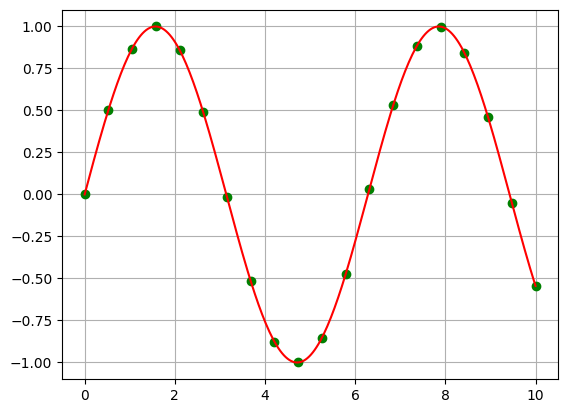

In [3]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.linspace(0,10,20)
y = np.sin(x)
f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(0,10,250)  # notice outside the original domain
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
frame.grid(True)
show()

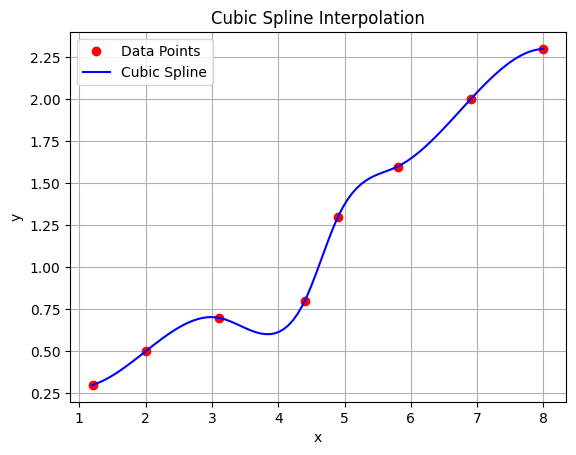

Unlike high-degree polynomials which can oscillate wildly near the edges of the domain, cubic splines provide a smooth and stable interpolation across the entire range.
Results for X_hat = 4.0:
Linear Y_hat:     0.7692
Polynomial Y_hat: 0.4937
Spline Y_hat:     0.6141


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, lagrange

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3])

#1
f_cubic = interp1d(x, y, kind='cubic')
x_plot = np.linspace(x.min(), x.max(), 100)
y_cubic = f_cubic(x_plot)

plt.figure()
plt.plot(x, y, 'ro', label='Data Points')
plt.plot(x_plot, y_cubic, 'b-', label='Cubic Spline')
plt.title('Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()
#2
print("Unlike high-degree polynomials which can oscillate wildly near the edges of the domain, cubic splines provide a smooth and stable interpolation across the entire range.")
# 3 & 4
class interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        
        # Linear
        self.func_linear = interp1d(x, y, kind='linear')
        # poly
        self.func_poly = lagrange(x, y)
        # Spline
        self.func_spline = interp1d(x, y, kind='cubic')
        
    def evaluate(self, X_hat, method):
        if method == 'linear':
            return self.func_linear(X_hat)
        elif method == 'polynomial':
            return self.func_poly(X_hat)
        elif method == 'spline':
            return self.func_spline(X_hat)
        else:
            raise ValueError("Invalid method. Choose 'linear', 'polynomial', or 'spline'.")

interp_obj = interpolation(x, y)
#5
X_hat = 4.0

y_hat_linear = interp_obj.evaluate(X_hat, method='linear')
y_hat_poly = interp_obj.evaluate(X_hat, method='polynomial')
y_hat_spline = interp_obj.evaluate(X_hat, method='spline')

print(f"Results for X_hat = {X_hat}:")
print(f"Linear Y_hat:     {y_hat_linear:.4f}")
print(f"Polynomial Y_hat: {y_hat_poly:.4f}")
print(f"Spline Y_hat:     {y_hat_spline:.4f}")

In [5]:
import numpy as np

def bilinear_interpolation(I, x, y):
    I_00 = I[0, 0] 
    I_10 = I[0, 1] 
    I_01 = I[1, 0] 
    I_11 = I[1, 1] 
    
    interpolated_val = (I_00 * (1 - x) * (1 - y) +
                        I_10 * x * (1 - y) +
                        I_01 * (1 - x) * y +
                        I_11 * x * y)
    
    return interpolated_val

I = np.array([[2.0, 4.1], 
              [2.5, 3.8]])

x_target = 0.2
y_target = 0.7

result = bilinear_interpolation(I, x_target, y_target)
print(f"The interpolated intensity at x={x_target}, y={y_target} is: {result:.3f}")

The interpolated intensity at x=0.2, y=0.7 is: 2.658


In [ ]:
data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]